# DATA 555 Project 2: Diabetes Diagnosis

Dataset: the downloaded `diabetes.csv` comes from https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset.

The target variable is `Outcome`, where 0 means no diabetes and 1 means diabetes.

The analysis uses Python, pandas, matplotlib, and scikit-learn.

Project repository: https://github.com/QihangFeng/data555-project2

## 1. Analyze the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path("diabetes.csv")
if not data_path.exists():
    data_url = "https://raw.githubusercontent.com/QihangFeng/data555-project2/refs/heads/main/diabetes.csv"
    urlretrieve(data_url, data_path)
    print("Downloaded diabetes.csv.")
else:
    print("diabetes.csv already exists; using the local file.")

diabetes.csv already exists; using the local file.


In [3]:
# Use the dataset already downloaded for this project.
df = pd.read_csv("diabetes.csv")
print(f"Dataset: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())

Dataset: 768 rows and 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Quality check

I check the column data types, missing values, duplicate records, numerical ranges, and whether `Outcome` contains only 0 and 1.
Zeroes in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are treated as missing measurements because zero is not considered a valid measurement for these variables in this dataset, based on prior medical knowledge. However, zeroes in `Pregnancies` are not treated as missing measurements because a woman may have no pregnancy history. (We cannot tell from the value alone whether a zero in `Pregnancies` represents a missing value or no pregnancy history, so we treat it as a valid zero rather than a missing value.)

In [4]:
missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
quality_check = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values in CSV": df.isna().sum(),
    "Zero-coded missing values": df[missing_columns].eq(0).sum().reindex(df.columns, fill_value=0)
})
display(quality_check)
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Outcome values other than 0 or 1: {(~df['Outcome'].isin([0, 1])).sum()}")
print(f"Negative numerical values: {df.lt(0).sum().sum()}")
display(df.describe().round(2))
display(df["Outcome"].value_counts().sort_index().rename("Records").to_frame())

,Data type,Missing values in CSV,Zero-coded missing values
Pregnancies,int64,0,0
Glucose,int64,0,5
BloodPressure,int64,0,35
SkinThickness,int64,0,227
Insulin,int64,0,374
BMI,float64,0,11
DiabetesPedigreeFunction,float64,0,0
Age,int64,0,0
Outcome,int64,0,0


Exact duplicate rows: 0
Outcome values other than 0 or 1: 0
Negative numerical values: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


,Records
Outcome,
0,500
1,268


In [5]:
# Mark missing measurements without changing the downloaded CSV.
data = df.copy()
data[missing_columns] = data[missing_columns].mask(data[missing_columns] == 0)
display(data.isna().sum().rename("Missing values after marking zeroes").to_frame())

,Missing values after marking zeroes
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [22]:
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1


There are no blank cells, exact duplicate rows, negative values, or `Outcome` values other than 0 or 1 in the CSV. However, `Insulin` has 374 zeroes treated as missing measurements, representing almost 49% of the records, and `SkinThickness` has 227; `Glucose`, `BloodPressure`, and `BMI` also contain some missing measurements. I retain all 768 records.

### Split the data into training and test sets

I use 80% of the records for training and 20% for testing, leaving 614 training records and 154 test records. Stratifying by `Outcome` keeps approximately 35% diabetes cases in both sets, and `random_state=42` makes the split reproducible. I use only the training records for exploratory plots and evaluate the models on the test records after choosing the final model.

In [6]:
X = data.drop(columns="Outcome")
y = data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training data: {X_train.shape[0]} records and {X_train.shape[1]} predictors")
print(f"Test data: {X_test.shape[0]} records and {X_test.shape[1]} predictors")
display(pd.DataFrame({
    "Training count": y_train.value_counts().sort_index(),
    "Test count": y_test.value_counts().sort_index(),
    "Training proportion": y_train.value_counts(normalize=True).sort_index(),
    "Test proportion": y_test.value_counts(normalize=True).sort_index()
}).round(3))
train_data = X_train.join(y_train)

Training data: 614 records and 8 predictors
Test data: 154 records and 8 predictors


,Training count,Test count,Training proportion,Test proportion
Outcome,,,,
0,400,100,0.651,0.649
1,214,54,0.349,0.351


### Predictor distributions

**The rationale of selecting this plot:** I chose histograms because they show how often different value ranges occur, helping me identify common values, wide spreads, and long tails in the predictors before model training.

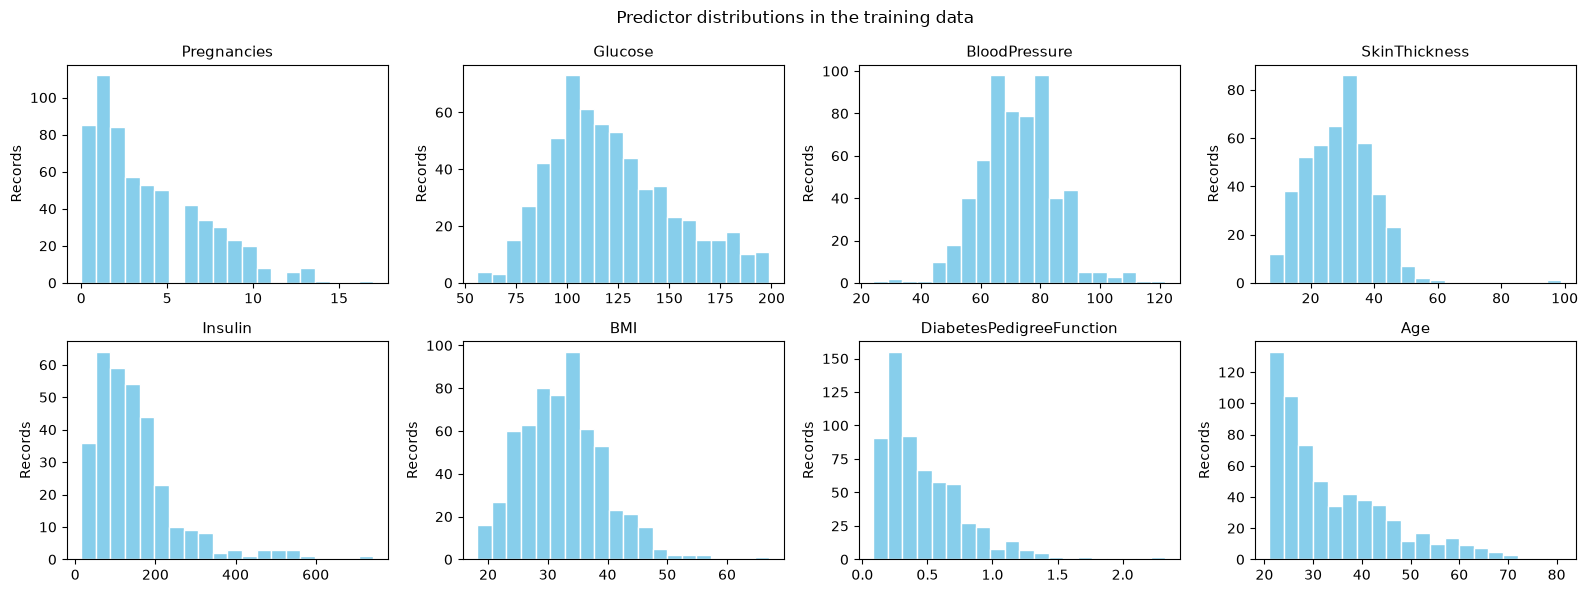

In [19]:
# Plot observed values only: zero-coded missing values in Glucose, BloodPressure,
# SkinThickness, Insulin, and BMI were marked as NaN and are excluded by dropna().
# Valid zero values in Pregnancies remain in its histogram.
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for column, ax in zip(X_train.columns, axes.flat):
    ax.hist(X_train[column].dropna(), bins=20, color="skyblue", edgecolor="white")
    ax.set_title(column, fontsize=11)
    ax.set_ylabel("Records")
fig.suptitle("Predictor distributions in the training data")
fig.tight_layout()
plt.show()

**My interpretation:** Age, pregnancies, insulin, and the diabetes pedigree function have right-skewed distributions, with most observations at lower values and fewer large values. Blood pressure and BMI have clear peaks around 70–80 and 30–35, respectively, with fewer observations at either end.

### Glucose and BMI by outcome

**The rationale of selecting this plot:** I chose box plots because differences in the median and spread of glucose and BMI between the diabetes and no-diabetes groups help me assess how useful these measurements may be for distinguishing diabetes from no diabetes.

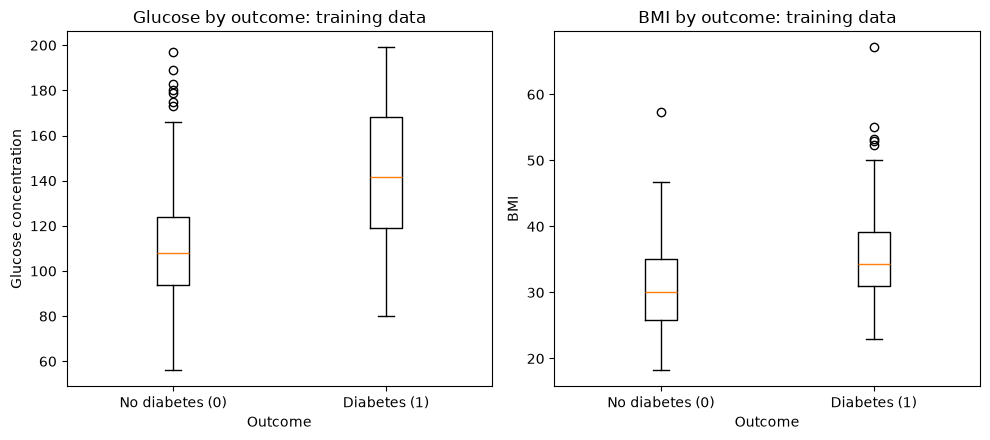

,Glucose,BMI
Outcome,,
0,108.0,30.1
1,141.5,34.3


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for column, ax in zip(["Glucose", "BMI"], axes):
    ax.boxplot(
        [train_data.loc[train_data["Outcome"] == outcome, column].dropna() for outcome in [0, 1]],
        tick_labels=["No diabetes (0)", "Diabetes (1)"]
    )
    ax.set_title(f"{column} by outcome: training data")
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Glucose concentration" if column == "Glucose" else "BMI")
fig.tight_layout()
plt.show()
display(train_data.groupby(by="Outcome")[["Glucose", "BMI"]].median().round(1))

**My interpretation:** The diabetes group has a higher median glucose, about 142 compared with 108, and a higher median BMI, about 34 compared with 30. Both plots show overlap between the groups, so neither measurement perfectly distinguishes the diabetes and no-diabetes groups.

## 2. Train a binary classifier 

I use logistic regression as the baseline for predicting `Outcome`. Its pipeline replaces missing measurements with each predictor's training median, subtracts the training mean and divides by the training standard deviation to scale each predictor, and fits the classifier using all eight predictors.

For five-fold stratified cross-validation, I divide the training records into five parts with similar proportions of the two outcomes. Each model is trained on four parts and evaluated on the remaining part, repeating until every part has been used for evaluation. All models use the same parts, and I compare their average scores.

Precision, recall, and F1 refer to diabetes (`Outcome=1`): precision measures the proportion of predicted diabetes cases that actually have diabetes, recall measures the proportion of actual diabetes cases the model detects, and F1 balances these two scores. I use F1 to choose predictors and model settings because it evaluates the less common diabetes class more directly than overall accuracy.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"Accuracy": "accuracy", "Precision": "precision", "Recall": "recall", "F1": "f1"}
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_cv = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring)
baseline_cv_metrics = {
    metric: baseline_cv[f"test_{metric}"].mean() for metric in scoring
}
display(pd.DataFrame([baseline_cv_metrics], index=["Baseline: mean validation scores"]).round(3))
baseline.fit(X_train, y_train)

models = {"Baseline logistic": baseline}
cv_f1_scores = {"Baseline logistic": baseline_cv_metrics["F1"]}

,Accuracy,Precision,Recall,F1
Baseline: mean validation scores,0.788,0.764,0.575,0.655


### Baseline performance and limitations

The baseline's mean validation F1 was 0.655, and recall was 0.575. It missed about 43% of diabetes cases on average across the validation folds, despite overall accuracy of about 79%. The model may miss nonlinear patterns, and using the same median for every missing measurement in a column cannot capture differences in those unrecorded measurements.

### Proposed improvements

I will test fewer predictors, then replace logistic regression with a random forest and tune its settings to see whether these changes increase validation F1.

## 3. Improve the model’s performance

### Step A: Feature selection

`SelectKBest` ranks each predictor by how much its average value differs between the diabetes and no-diabetes groups relative to variation within the groups (the ANOVA F score). I compare keeping the 3, 5, or 7 highest-ranked predictors while keeping the logistic regression settings unchanged. For each validation split, I calculate replacement medians and rank predictors using only the four training parts.

In [11]:
selected_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("select", SelectKBest(score_func=f_classif)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
feature_search = GridSearchCV(
    selected_logistic,
    param_grid={"select__k": [3, 5, 7]},
    scoring=scoring,
    refit="F1",
    cv=cv,
    error_score="raise"
)
feature_search.fit(X_train, y_train)
selected_model = feature_search.best_estimator_
selected_k = feature_search.best_params_["select__k"]
feature_results = pd.DataFrame({
    "Features retained": feature_search.cv_results_["param_select__k"],
    "Mean validation F1": feature_search.cv_results_["mean_test_F1"],
    "F1 standard deviation": feature_search.cv_results_["std_test_F1"]
})
display(feature_results.round(3))

selector = selected_model.named_steps["select"]
selected_features = X_train.columns[selector.get_support()].tolist()
print(f"Selected features ({selected_k}): {', '.join(selected_features)}")
display(pd.DataFrame({
    "F score": selector.scores_,
    "Selected": selector.get_support()
}, index=X_train.columns).sort_values(by="F score", ascending=False).round(2))

models["Selected-feature logistic"] = selected_model
cv_f1_scores["Selected-feature logistic"] = feature_search.best_score_

,Features retained,Mean validation F1,F1 standard deviation
0,3,0.641,0.035
1,5,0.641,0.034
2,7,0.652,0.022


Selected features (7): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Age


,F score,Selected
Glucose,217.76,True
BMI,74.17,True
Insulin,39.39,True
Age,37.63,True
SkinThickness,35.54,True
Pregnancies,27.72,True
BloodPressure,21.29,True
DiabetesPedigreeFunction,17.19,False


The feature search selected seven predictors, and the selector fitted on all training records left out `DiabetesPedigreeFunction`. Logistic regression using seven predictors had mean validation F1 of 0.652, below 0.655 for the baseline using all eight predictors, so feature selection did not improve validation F1.

### Step B: Train the alternative model

I use a random forest to learn nonlinear patterns and combinations of predictor values that logistic regression may miss. I still select seven predictors and replace missing values with medians. Scaling is unnecessary because each tree split compares values within one predictor.

In [12]:
forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("select", SelectKBest(score_func=f_classif, k=selected_k)),
    ("model", RandomForestClassifier(random_state=42))
])
forest_cv = cross_validate(forest, X_train, y_train, cv=cv, scoring=scoring)
forest_cv_metrics = {
    metric: forest_cv[f"test_{metric}"].mean() for metric in scoring
}
display(pd.DataFrame([forest_cv_metrics], index=["Random forest: mean validation scores"]).round(3))
forest.fit(X_train, y_train)
models["Random forest"] = forest
cv_f1_scores["Random forest"] = forest_cv_metrics["F1"]

,Accuracy,Precision,Recall,F1
Random forest: mean validation scores,0.764,0.693,0.594,0.637


The untuned forest's mean validation F1 was 0.637, lower than 0.652 for logistic regression using seven predictors. It detected a slightly larger proportion of diabetes cases, but a larger proportion of its diabetes predictions were incorrect.

### Step C: Tune the random forest

I use `GridSearchCV` to compare 32 combinations of forest settings and choose the combination with the highest mean validation F1. Limiting tree depth and requiring more records in each final tree group (leaf) can help the trees avoid learning patterns based on only a few training records. Balanced class weights make each diabetes record count more during training because there are fewer diabetes records than no-diabetes records.

In [13]:
parameter_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt", 1.0],
    "model__class_weight": [None, "balanced"]
}
forest_search = GridSearchCV(
    forest,
    param_grid=parameter_grid,
    scoring=scoring,
    refit="F1",
    cv=cv,
    n_jobs=1,
    error_score="raise"
)
forest_search.fit(X_train, y_train)
tuned_forest = forest_search.best_estimator_
print(f"Best mean validation F1: {forest_search.best_score_:.3f}")
display(pd.Series(forest_search.best_params_, name="Best setting").to_frame())
best_index = forest_search.best_index_
tuned_cv_metrics = {
    metric: forest_search.cv_results_[f"mean_test_{metric}"][best_index] for metric in scoring
}
display(pd.DataFrame([tuned_cv_metrics], index=["Tuned forest: mean validation scores"]).round(3))
models["Tuned random forest"] = tuned_forest
cv_f1_scores["Tuned random forest"] = forest_search.best_score_

Best mean validation F1: 0.690


,Best setting
model__class_weight,balanced
model__max_depth,5
model__max_features,1.0
model__min_samples_leaf,3
model__n_estimators,200


,Accuracy,Precision,Recall,F1
Tuned forest: mean validation scores,0.761,0.633,0.762,0.69


Tuning increased mean validation F1 from 0.637 to 0.690. The tuned forest detected more diabetes cases in validation, but a larger proportion of its diabetes predictions were incorrect.

### Choose the final model using validation F1

In [14]:
cv_comparison = pd.DataFrame({"Mean validation F1": cv_f1_scores}).rename_axis("Model")
display(cv_comparison.round(3))
best_model_name = cv_comparison["Mean validation F1"].idxmax()
best_model = models[best_model_name]
print(f"Model chosen from training cross-validation: {best_model_name}")

,Mean validation F1
Model,
Baseline logistic,0.655
Selected-feature logistic,0.652
Random forest,0.637
Tuned random forest,0.690


Model chosen from training cross-validation: Tuned random forest


The tuned random forest has the highest mean validation F1, so I choose it as the final model. I used the same validation splits to choose predictors and settings, so these validation F1 scores may be higher than the model would achieve on new data; the test set provides a separate check.

## 4. Final evaluation on the reserved test set

I evaluate the fitted models on the reserved test set to compare their performance. For comparison, I also use a reference classifier that always predicts `Outcome = 0` (no diabetes), since this is the more common outcome in the training data.

In [15]:
majority_model = DummyClassifier(strategy="most_frequent")
majority_model.fit(X_train, y_train)
evaluation_models = {"Always predicts 0": majority_model}
evaluation_models.update(models)

metric_rows = []
test_predictions = {}
for model_name, model in evaluation_models.items():
    y_pred = model.predict(X_test)
    test_predictions[model_name] = y_pred
    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })
result_df = pd.DataFrame(metric_rows).set_index("Model")
display(result_df.round(3))
print(f"Model selected before test evaluation: {best_model_name}")

,Accuracy,Precision,Recall,F1
Model,,,,
Always predicts 0,0.649,0.000,0.000,0.000
Baseline logistic,0.708,0.600,0.500,0.545
Selected-feature logistic,0.708,0.592,0.537,0.563
Random forest,0.721,0.608,0.574,0.590
Tuned random forest,0.753,0.611,0.815,0.698


Model selected before test evaluation: Tuned random forest


### Baseline test performance

On the test set, logistic regression achieved 70.8% accuracy, 0.600 precision, 0.500 recall, and F1 of 0.545, compared with 64.9% accuracy for the classifier that always predicts 0 (no diabetes). It identified only half of the diabetes cases, missing 27 of 54, despite 70.8% overall accuracy.

### Test performance changes at every step

Feature selection increased test F1 slightly, from 0.545 to 0.563, and changing to the untuned forest raised it to 0.590. Tuning gave the largest gain, bringing F1 to 0.698. Feature selection and the untuned forest both lowered validation F1 compared with the previous step, so their test gains were not consistent across validation and test data.

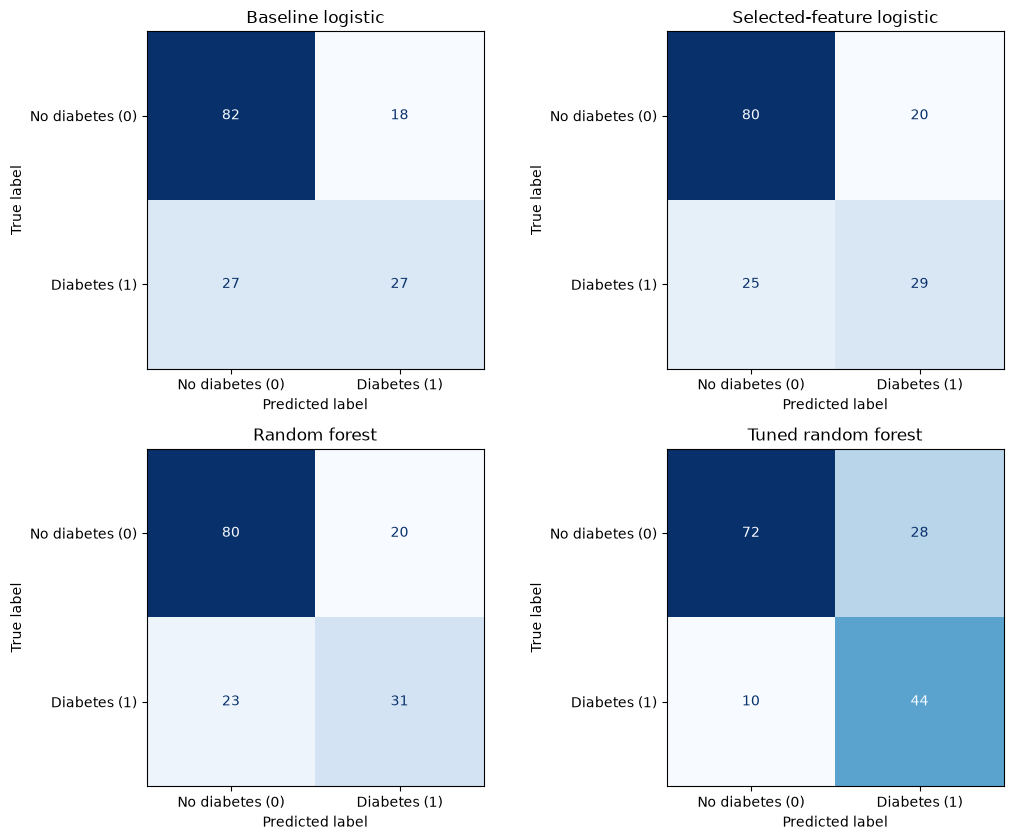

In [16]:
# Compare the types of errors made by each model.
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for (model_name, model), ax in zip(models.items(), axes.flat):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions[model_name],
        display_labels=["No diabetes (0)", "Diabetes (1)"],
        values_format="d",
        cmap="Blues",
        colorbar=False,
        ax=ax
    )
    ax.set_title(model_name)
fig.tight_layout()
plt.show()

I chose confusion matrices to see how many diabetes cases each model missed and how many no-diabetes records it incorrectly predicted as diabetes; the rows show actual outcomes and the columns show predictions. The tuned forest correctly identified 44 of the 54 diabetes cases, compared with 27 for the baseline. However, it incorrectly predicted diabetes for 28 of the 100 no-diabetes records, compared with 18 for the baseline.

### Conclusion

Tuning the random forest produced the largest F1 improvement, while feature selection alone did not consistently improve F1 across validation and test data. The missing insulin and skin thickness measurements, median replacement, and small test set limit how confident I can be that the model will perform as well on new records.